# NUMERICAL EXPERIMENTS "Personalized Federated Learning via Active Sampling"

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

plt.rcParams.update({'axes.spines.right': False,
                     'axes.spines.top': False})

## A. Toy Datasets

Each local dataset $D^{(i)}$ consists of $m_i$ realizations of i.i.d. random variables with a common probability distribution $p^{(i)}$ (Eq.(9)).

Each data point is characterized by a feature vector $\mathbf{x}^{(i,r)} \in R^d$ and a scalar label $y^{(i,r)}$, for $r = 1,...,m_i$. It would be convenient to stack the feature vectors and labels of a local dataset $D^{(i)}$, into a feature matrix and label vector, respectively (see Eq.(10)).

The feature vectors $\mathbf{x}^{(i,r)} ∼ N(0,I_{d×d})$, are drawn i.i.d. from a standard multivariate normal distribution. The labels $y^{(i,r)}$ of the data points are modeled as a noisy linear combination of the corresponding features $\mathbf{x}^{(i,r)}$ (see Eq.(11)).

The noise $\epsilon^{(i)} ∼ N(0,I)$, for $i ∈ V$ and $r = 1,...,m_i$, are i.i.d. realizations of a standard normal distribution. The noise variance $\sigma^2 ≥ 0$ in (Eq. (11)) is assumed fixed.

In [48]:
def gen_ds(n_clusters, n_ds, n_samples, n_features, noise_scale=1.0):
    
    """
    
    Function to create noisy Gaussian regression datasets multivar Gaussian ~N(0,I). 
    Datasets within the cluster share the same true weight vector. 
    For each node we create training (size = n_samples) and validation (size = 100) ds.
    
    Args:
    : n_clusters  : int, number of clusters
    : n_ds        : list of len(n_clusters), number of local datasets per cluster 
    : n_samples   : number of samples in a local dataset
    : n_features  : number of features of a datapoint
    : noise_scale : scale of normal distribution used to generate data noise
    
    Out:
    : ds_train       : tuple (X_train, y_train), where X array of shape (n_nodes, m_i, d) and y - (n_nodes, m_i, 1)
    : ds_val         : tuple (X_val ,y_val), where X array of shape (n_nodes, m_i, d) and y - (n_nodes, m_i, 1)
    : cluster_labels : list of len(n_ds) cluster assignments for each local dataset 
    : true_weights   : array of shape (n_clusters, n_features), true weight vector for each cluster

    """
    
    # Lists to store and return outputs

    cluster_labels = []
    m_val = 100 # hardcoded size of the validation set
    n_nodes = sum(n_ds)
    X_train, y_train = np.zeros((n_nodes, n_samples, n_features)), np.zeros((n_nodes, n_samples, 1))
    X_val, y_val = np.zeros((n_nodes, m_val, n_features)), np.zeros((n_nodes, m_val, 1))
    
    true_weights   = np.zeros((n_clusters, n_features))

    node_id = 0
    for i in range(n_clusters):
    
        # Sample true weight vector for cluster i
        #w = np.random.normal(0, 1, size=(n_features,1))
        w = np.random.uniform(-5, 5, size=(n_features,1))
        true_weights[i] = w.reshape(-1,)

        for j in range(n_ds[i]):
            # Sample datapoints from multivar Gaussian ~N(0,I)
            X = np.random.normal(0, 1.0, size=(n_samples + m_val, n_features))
            
            # Sample noise 
            noise = np.random.normal(loc=0.0, scale=noise_scale, size=(n_samples + m_val, 1))
            
            # Noisy Gaussian regression
            y = X@w + noise

            # Split train vs val
            X_t, X_v, y_t, y_v = train_test_split(X, y, train_size=n_samples, test_size=m_val)
            X_train[node_id] = X_t
            y_train[node_id] = y_t
            
            X_val[node_id] = X_v
            y_val[node_id] = y_v
            
            # ds_train.append( (X_train, y_train) )
            # ds_val.append( (X_val, y_val) )
            
            cluster_labels.append(i)
            node_id += 1

    return (X_train, y_train), (X_val, y_val), cluster_labels, true_weights

In [49]:
def resample_ds(ds_train, ds_val, cluster_labels, true_weights, noise_scale):
    
    n_clusters = len(set(cluster_labels))
    n_nodes, n_samples, n_features = ds_train[0].shape
    m_val = ds_val[0][0].shape[0]
    
    # randomly replace a cluster
    idx = np.random.choice(np.arange(1, n_clusters))
    idx_to_replace = np.where(np.array(cluster_labels)==idx)[0]

    # sample new weight vector
    w = np.random.uniform(-5, 5, size=(n_features,1))
    true_weights[idx] = w.reshape(-1,)

    for i in idx_to_replace:
        # Sample datapoints from multivar Gaussian ~N(0,I)
        X = np.random.normal(0, 1.0, size=(n_samples + m_val, n_features))
        
        # Sample noise 
        noise = np.random.normal(loc=0.0, scale=noise_scale, size=(n_samples + m_val, 1))
        
        # Noisy Gaussian regression
        y = X@w + noise
    
        # Split train vs val
        X_t, X_v, y_t, y_v = train_test_split(X, y, train_size=n_samples, test_size=m_val)
        ds_train[0][i] = X_t
        ds_train[1][i] = y_t
        
        ds_val[0][i] = X_v
        ds_val[1][i] = y_v

    return ds_train, ds_val, cluster_labels, true_weights

# Parametric Models (Experiments B-E)

## Linear PersFL

We generated different collections of local datasets by varying the ratio $d/m \in \{ 0.2, 1, 2, 5, 10\}$ between number of features and size of local datasets. 
We measure the quality of the learnt local model parameter $\widehat{\mathbf{w}}^{(i)}$ using the squared Euclidean norm 
$
\begin{equation}
{\rm MSE} = ||{\widehat{\mathbf{w}}-  \overline{\mathbf{w}}^{(1)}}||_{2}^{2}
\end{equation}
$

In [50]:
# def weight_update(subset, weights, eta):
    
#     """
#     Function to compute loss, gradient and weight updates on subset of the clients D^(i´).
#     Implements Eqs.(1,13).
    
#     Args:
    
#     : subset    : tuple (X,y), where X array of shape (B, m_i, d) and y - (B, m_i, 1),
#                   randomly selected subset of data (see Line 3 of Algo 1)
#     : weights   : array of shape (d, 1), weight vector, w_hat in Eq.(1)
#     : eta       : scalar, scaling param, see Eq.(1)

#     Out:

#     : w_updated : array of shape (B, d), updated weight vector for each dataset D^(i´) in the subset, 
#                   w_tilde^(i´) in Eq.(1,4)
    
#     """
    
#     S, d = len(subset[0]), weights.shape[0]
    
#     # Store updated weights
#     w_updated = np.zeros((S, d))
    
#     # For each dataset D^(i´) in the subset compute updated weight vector w_tilde^(i´) according to Eq.(1)
#     for i in range(S):
#         # get D^(i´)
#         X, y = subset[0][i], subset[1][i]
#         # compute local loss L^(i´) incurred by a model parameters w_hat on dataset D^(i´), 
#         # loss L^(i´) is defined as in Eq.(13)
#         loss = np.mean((y - X@weights)**2)
#         # compute gradient \nabla L^(i´)(w_hat) in Eq.(1)
#         grad = (-2/len(y))*X.T@(y - X@weights)
#         # update weight vector w_hat according to Eq.(1,4)
#         w_updated[i] = (weights - eta*grad).reshape(-1,)
    
#     return w_updated

def weight_update(subset, weights, eta):
    S, d = len(subset[0]), weights.shape[0]

    # force float32
    weights = weights.astype(np.float32)
    eta = np.float32(eta)

    w_updated = np.zeros((S, d), dtype=np.float32)

    for i in range(S):
        X = subset[0][i].astype(np.float32)
        y = subset[1][i].astype(np.float32)

        # loss (same as torch MSELoss(reduction="mean"))
        loss = np.mean((y - X @ weights) ** 2, dtype=np.float32)

        # gradient (EXACT match to torch)
        grad = (-2.0 / y.shape[0]) * (X.T @ (y - X @ weights))

        grad = grad.astype(np.float32)

        w_updated[i] = (weights - eta * grad).reshape(-1).astype(np.float32)

    return w_updated

def choose_candidate(D1, w_updated):

    """
    Function to determine candidate with smallest loss i_0 on dataset D^(1).
    Implements Eq.(3).
    
    Args:
    
    : D1        : tuple (X,y), dataset D^(1) where X of shape (m_i, d), y - (m_i, 1)
    : w_updated : array of shape (B, d), updated weight vector, w_tilde^(i´) in Eq.(1)

    Out:

    Return weight vector which incur smallest loss on the dataset D^(1) and correponding loss value  
    (i_0 in the paper, see Eq.(3))
    
    """
    
    X, y, m = D1[0], D1[1], len(D1[1])
    errors = y.reshape(1, m) - w_updated@X.T # shape (B, m)
    loss = np.mean(errors**2, axis=1) # shape (B,)
    # determine candidate with a smallest loss on dataset D^(1), Eq.(3) 
    candidate_idx = np.argmin(loss)

    # return weight vector and loss value of the candidate i_0
    return w_updated[candidate_idx].reshape(-1,1), loss[candidate_idx]

In [51]:
def train(ds_train, cluster_labels, true_weights, R, eta, B, weights=None, oracle=False):

    """
    Function to create datasets and implement Algorithm 1  "PersFL for Parametric Models".
    
    Args:
    
    : ds_train     : tuple (X_train, y_train), where X array of shape (n_nodes, m_i, d) and y - (n_nodes, m_i, 1)
    : true_weights : array of shape (n_clusters, n_features), true weight vector for each cluster
    : R            : scalar, number of iterations
    : eta          : scalar, scaling param eta in Eq.(1)
    : B            : scalar, size of randomly chosen subset of the clients
    
    Out:

    : losses      : array of len (R), loss values on each iteration given by the best candidate, 
                   Eq.(3) l_i0 in the paper
    
    """
    
    # Select dataset D_(1) with true weight vector corresponding to the first cluster
    D1 = (ds_train[0][0], ds_train[1][0])

    # Init model weights (w_hat:=0 Line 1 of Algo 1)
    if weights is None: weights = np.zeros((ds_train[0].shape[2], 1))
    
    # training loop
    MSE = np.zeros((R)) # Eq.(14) compute MSE := ||w_hat - w_true^(1)||^2
    for i in range(R):
        # Line 3 of Algo 1, select a subset of clients
        idx = np.random.choice(np.arange(len(ds_train[0]))[1:], B, replace=False)
        subset = (ds_train[0][idx], ds_train[1][idx]) 
        cluster_ids = np.array(cluster_labels)[idx]
  
        # Line 4 of Algo 1. Update weight vector w_hat on clients' datasets (according to Eq.(1))
        w_updated = weight_update(subset, weights, eta)
        
        if oracle:
            # get indices of all local datasets with cluster label 0
            idx_cluster1 = np.where(cluster_ids==0)[0]
            if len(idx_cluster1) == 0:
                 weights, _ = choose_candidate(D1, w_updated)
                 print("Oracle, no cluster 1 nodes")
            else:
                # randomly select updated vector weight from them
                weights = w_updated[np.random.choice(idx_cluster1, 1, replace=False)[0]].reshape(-1,1)
        else:
            # Line 5,6 of Algo 1. Compute loss on local dataset D1 and choose best candidate (according to Eq.(3))
            weights, _ = choose_candidate(D1, w_updated)
            
        # Eq.(14) compute MSE := ||w_hat - w_true^(1)||^2          
        MSE[i] = np.sum((true_weights[0].reshape(-1,1) - weights)**2) / len(weights)
    return MSE, weights

In [52]:
def train_local(D1, true_weights, R, eta):
    X, y = D1[0], D1[1]
    m, d = X.shape
    weights = np.zeros((d, 1))
    
    # training loop
    MSE = np.zeros((R)) # Eq.(14) compute MSE := ||w_hat - w_true^(1)||^2
    for i in range(R):
        w_updated = weight_update((X[np.newaxis,:,:], y[np.newaxis,:,:]), weights, eta)
        weights   = w_updated[0].reshape(-1,1)
        MSE[i]    = np.sum((true_weights[0].reshape(-1,1) - weights)**2) / len(weights)
    return MSE

### Clustered dataset, balanced
We generate $n = 100$ local datasets according to Eq.(11) with the true underlying parameter $\overline{\mathbf{w}}^{(i)}$ being clustered into two equal-sized 
clusters, $\mathcal{C}_{1}$ and $\mathcal{C}_{2}$ with $n_{1}=n_{2}=50$. 
For each cluster, we generate a parameter vector $\mathbf{w}^{(i)}$ by filling its entries 
with i.i.d. samples of a uniform distribution $\mathcal{U}_{[-5, 5]}$. Each client possesses feature 
vectors (independently and identically sampled from a standard multivariate normal distribution) of size $d$, comprising $m_i=m=10$ samples. 
The labels assigned to the data points are modelled as a noisy linear combination of the  respective features and weight vectors unique to each cluster. 

In [53]:
save_data = True

***Figure 2a - Different d/m ratio (noise=0, S=20)***

In [58]:
#----------------Balanced clustered dataset (|C_1|=|C_2|=50)---------------------#
n_clusters = 2           # n.o. clusters 
n_i        = [50, 50]    # n.o. local datasets per cluster
m_i        = 10          # n.o. samples in local dataset
# try out different d/m ratios (keep m=10 and vary d)
# d/m = 0.2, 1, 2, 5, 10 ~> d = 2, 10, 20, 50, 100
dims       = [2, 10, 50, 100]    # d, dimentionality of the feature vector
eta        = 0.025       # learning rate
R          = 1500        # n.o. iterations
sigma      = 0           # noise
S          = 20          # batch size
reps       = 3          # repeatitions of the experiment 

In [59]:
# Algo 1 with different d/m ratio
def experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S):
    
    mse = np.zeros((len(dims), R))
    for i, d in enumerate(dims):  
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        # pytorch weights U(-sqrt(1/d), sqrt(1/d))
        weights = np.random.uniform(-np.sqrt(d), np.sqrt(d), (d,1))
        mse[i], _ = train(ds_train, cluster_labels, true_weights, R, eta, S, weights=weights)
    return mse

mse_reps = np.zeros((reps, len(dims), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

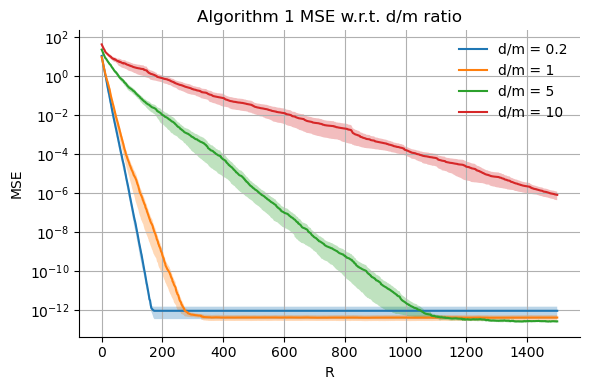

In [60]:
# Plot with shaded error bars (mean ± SEM)
labels = ['d/m = 0.2', 'd/m = 1', 'd/m = 5', 'd/m = 10']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(dims)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('Algorithm 1 MSE w.r.t. d/m ratio')
plt.grid(True)
plt.tight_layout()
plt.show()

In [91]:
if save_data:
    df = pd.DataFrame(data=(np.vstack([mean_mse, sem_mse])).T)
    df.to_csv('Algo1_dm_ratio_mean_sem.csv', mode='a', index=True, header=None)

#### PersFL vs Local vs Oracle with noise $\sigma=0.01$

In [100]:
#----------------Balanced clustered dataset (|C_1|=|C_2|=50)---------------------#
n_clusters = 2           # n.o. clusters 
n_i        = [50, 50]    # n.o. local datasets per cluster
m_i        = 10          # n.o. samples in local dataset
dims       = [2, 10, 20, 50, 100]    # d, dimentionality of the feature vector
eta        = 0.05        # learning rate
R          = 1500        # n.o. iterations
sigma      = 0.1         # noise
S          = 20          # batch size
reps       = 10          # repeatitions of the experiment 

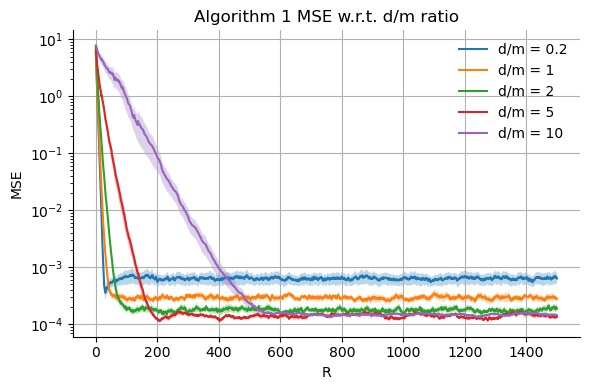

In [101]:
# Algo 1 with different d/m ratio
def experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S):
    
    mse = np.zeros((len(dims), R))
    for i, d in enumerate(dims):  
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        mse[i], _ = train(ds_train, cluster_labels, true_weights, R, eta, S)
    return mse

mse_reps = np.zeros((reps, len(dims), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

# Plot with shaded error bars (mean ± SEM)
labels = ['d/m = 0.2', 'd/m = 1', 'd/m = 2', 'd/m = 5', 'd/m = 10']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(dims)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('Algorithm 1 MSE w.r.t. d/m ratio')
plt.grid(True)
plt.tight_layout()
plt.show()

In [102]:
if save_data:
    df = pd.DataFrame(data=(np.vstack([mean_mse, sem_mse])).T)
    df.to_csv('Algo1_dm_ratio_mean_sem_noise0.1.csv', mode='a', index=True, header=None)

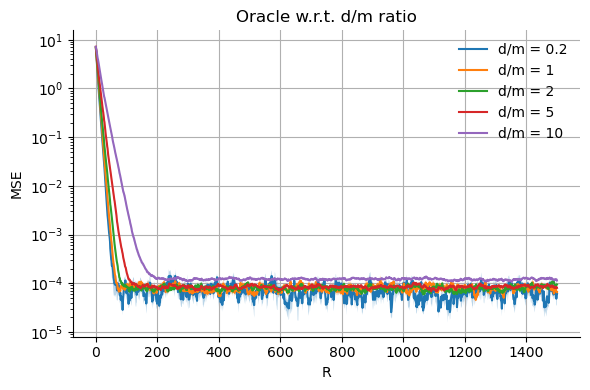

In [95]:
# Algo 1 with different d/m ratio
def experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S):
    
    mse = np.zeros((len(dims), R))
    for i, d in enumerate(dims):  
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        mse[i], _ = train(ds_train, cluster_labels, true_weights, R, eta, S, oracle=True)
    return mse

mse_reps = np.zeros((reps, len(dims), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

# Plot with shaded error bars (mean ± SEM)
labels = ['d/m = 0.2', 'd/m = 1', 'd/m = 2', 'd/m = 5', 'd/m = 10']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(dims)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('Oracle w.r.t. d/m ratio')
plt.grid(True)
plt.tight_layout()
plt.show()

In [96]:
if save_data:
    df = pd.DataFrame(data=(np.vstack([mean_mse, sem_mse])).T)
    df.to_csv('Oracle_dm_ratio_mean_sem_noise0.1.csv', mode='a', index=True, header=None)

In [97]:
# Local training
def experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S):
    mse = np.zeros((len(dims), R))
    for i, d in enumerate(dims):  
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        mse[i] = train_local((ds_train[0][0], ds_train[1][0]), true_weights, R, eta)
    return mse

mse_reps = np.zeros((reps, len(dims), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

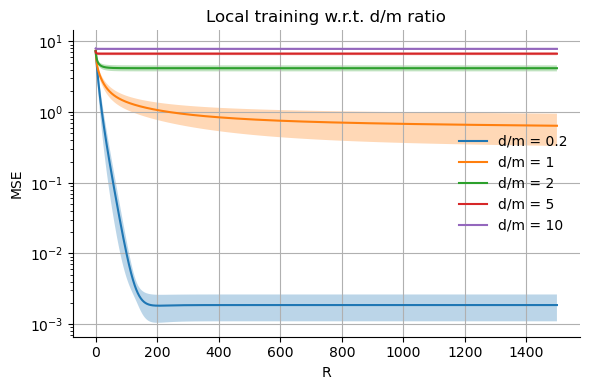

In [98]:
# Plot with shaded error bars (mean ± SEM)
labels = ['d/m = 0.2', 'd/m = 1', 'd/m = 2', 'd/m = 5', 'd/m = 10']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(dims)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('Local training w.r.t. d/m ratio')
plt.grid(True)
plt.tight_layout()
plt.show()

In [99]:
if save_data:
    df = pd.DataFrame(data=(np.vstack([mean_mse, sem_mse])).T)
    df.to_csv('Local_dm_ratio_mean_sem_noise0.1.csv', mode='a', index=True, header=None)

***Figure 2b - Different noise levels (d/m=2, S=20)***

In [ ]:
n_clusters = 2           # n.o. clusters 
n_i        = [50, 50]    # n.o. local datasets per cluster
m_i        = 10          # n.o. samples in local dataset
d          = 50          # dimentionality of the feature vector
eta        = 0.05        # learning rate
R          = 1500        # n.o. iterations
# try out different noise levels
sigmas     = [0.001, 0.01, 0.1, 1.0]           # noise
S          = 20          # batch size
reps       = 10          # repeatitions of the experiment 

In [ ]:
# Algo 1 with different values for noise
def experiment(n_clusters, n_i, m_i, d, etas, R, sigmas, S):
    
    mse = np.zeros((len(sigmas), R))
    for i, sigma in enumerate(sigmas): 
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        mse[i], _ = train(ds_train, cluster_labels, true_weights, R, eta, S)
    return mse

In [ ]:
mse_reps = np.zeros((reps, len(sigmas), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, d, eta, R, sigmas, S)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

In [ ]:
# Plot with shaded error bars (mean ± SEM)
labels = [r'$\sigma$ = 0.001', r'$\sigma$ = 0.01', r'$\sigma$ = 0.1', r'$\sigma$ = 1.0']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(sigmas)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title(r'Algorithm 1 MSE w.r.t. $\sigma$')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
if save_data:
    df = pd.DataFrame(data=(np.vstack([mean_mse, sem_mse])).T)
    df.to_csv('Algo1_noise_mean_sem.csv', mode='a', index=True, header=None)

***Figure 2c - Different subset size S (d/m=2, noise=0)***

In [ ]:
n_clusters = 2           # n.o. clusters 
n_i        = [50, 50]    # n.o. local datasets per cluster
m_i        = 10          # n.o. samples in local dataset
d          = 50          # dimentionality of the feature vector
eta        = 0.05        # learning rate
R          = 2000         # n.o. iterations
sigma      = 0           # noise
Ss         = [5, 10, 15, 20, 30]    # batch size
reps       = 10          # repeatitions of the experiment 

In [ ]:
# Algo 1 with different values for noise
def experiment(n_clusters, n_i, m_i, d, etas, R, sigmas, Ss):
    
    mse = np.zeros((len(Ss), R))
    for i, S in enumerate(Ss): 
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        mse[i], _ = train(ds_train, cluster_labels, true_weights, R, eta, S)
    return mse

In [ ]:
mse_reps = np.zeros((reps, len(Ss), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, d, eta, R, sigma, Ss)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

In [ ]:
# Plot with shaded error bars (mean ± SEM)
labels = ['S = 5', 'S = 10', 'S = 15', 'S = 20', 'S = 30']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(Ss)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title(r'Algorithm 1 MSE w.r.t. $\sigma$')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
if save_data:
    df = pd.DataFrame(data=(np.vstack([mean_mse, sem_mse])).T)
    df.to_csv('Algo1_B_mean_sem.csv', mode='a', index=True, header=None)

### Clustered dataset, imbalanced
We generate $n = 100$ local datasets according to Eq.(11) with the true underlying parameter $\overline{\mathbf{w}}^{(i)}$ being clustered into two unequal-sized 
clusters, $\mathcal{C}_{1}$ and $\mathcal{C}_{2}$. 
For each cluster, we generate a parameter vector $\mathbf{w}^{(i)}$ by filling its entries 
with i.i.d. samples of a uniform distribution $\mathcal{U}_{[-5, 5]}$. Each client possesses feature 
vectors (independently and identically sampled from a standard multivariate normal distribution) of size $d$, comprising $m_i=m=10$ samples. 
The labels assigned to the data points are modelled as a noisy linear combination of the  respective features and weight vectors unique to each cluster. 

In [ ]:
n_clusters = 2           # n.o. clusters 
n_is       = [[5, 95], [20, 80], [40, 60], [80, 20]]    # n.o. local datasets per cluster
m_i        = 10          # n.o. samples in local dataset
d          = 50          # dimentionality of the feature vector
eta        = 0.05        # learning rate
R          = 500        # n.o. iterations
sigma      = 0           # noise
S          = 99          # batch size
reps       = 10          # repeatitions of the experiment 

In [ ]:
# Algo 1 with different d/m ratio
def experiment(n_clusters, n_is, m_i, d, eta, R, sigma, S):
    
    mse = np.zeros((len(n_is), R))
    for i, n_i in enumerate(n_is):  
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        mse[i], _ = train(ds_train, cluster_labels, true_weights, R, eta, S)
    return mse

In [ ]:
mse_reps = np.zeros((reps, len(n_is), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_is, m_i, d, eta, R, sigma, S)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

In [ ]:
# Plot with shaded error bars (mean ± SEM)
labels = ['0.05','0.2', '0.4', '0.8']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(n_is)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('Algorithm 1 MSE w.r.t. prop. of same cluster datasets')
plt.grid(True)
plt.tight_layout()
plt.show()

## Benchmarking on Heterogenous dataset

### Baseline for FedProx, IFCA

In [ ]:
#-----------------------FedProx------------------------#

In [ ]:
# ------- Local Client Training (FedProx) -------
def local_train_fedprox(X, y, w_global, lr=0.01, epochs=5, mu=0.1):
    w = w_global.copy()
    m = len(y)
    for _ in range(epochs):
        preds = X @ w
        grad = (2 / m) * X.T @ (preds - y)
        # Add FedProx proximal term
        prox_term = mu * (w - w_global)
        w -= lr * (grad + prox_term)
    return w

# ------- Main FedProx Simulation -------
def FedProx(ds_train, true_weights, R, local_R, eta=0.05, mu=0.1):
    """
    Function to create datasets and implement Algorithm 1  "PersFL for Parametric Models".
    
    Args:
    
    : ds_train     : tuple (X_train, y_train), where X array of shape (n_nodes, m_i, d) and y - (n_nodes, m_i, 1)
    : true_weights : array of shape (n_clusters, n_features), true weight vector for each cluster
    : R            : scalar, number of iterations
    : eta          : scalar, scaling param eta in Eq.(1)
    : B            : scalar, size of randomly chosen subset of the clients
    
    Out:

    : losses      : array of len (R), loss values on each iteration given by the best candidate, 
                   Eq.(3) l_i0 in the paper
    
    """
    
    X_train, y_train = ds_train[0], ds_train[1]
    n_nodes, m_i, d = X_train.shape
    w_global = np.zeros((d,1))

    MSE = np.zeros((R)) 
    for r in range(R):
        local_weights = []
        for i in range(n_nodes):
            # local updates
            w_local = local_train_fedprox(X_train[i], y_train[i], w_global, eta, local_R, mu)
            local_weights.append(w_local)

        w_global = np.mean(local_weights, axis=0) # aggregation step
        MSE[r] = np.sum((true_weights[0].reshape(-1,1) - local_weights[0].reshape(-1,1))**2) / d

    return MSE

In [ ]:
#-----------------------IFCA------------------------#

In [ ]:
def compute_grads(subset, weights):
    
    """
    
    Function to compute cluster identity estimate, gradients and loss.
    Implements Lines 5-9 of Algo 2 "Iterative Federated Clustering Algorithm (IFCA)".
    
    Args:
    
    : subset  : tuple (X,y), where X of shape (S, m_i, d), y - (S, m_i, 1),
                randomly selected subset of data
    : weights : array of shape (n_clusters, d), cluster weight vectors, theta^t_j

    Out:

    : cluster_labels : array of shape (n_clients), estimated cluster identity
    : grads          : array of shape (n_clients, d), gradient corresponding to chosen cluster identity
    : l              : array of shape (n_clients), loss corresponding to chosen cluster identity
    
    """
    
    Xs, ys = subset[0], subset[1]
    n_clients, m, n_clusters, d = ys.shape[0], ys.shape[1], weights.shape[0], weights.shape[1]
    
    cluster_labels = np.zeros((n_clients))
    # for each weight vector/cluster compute loss and gradient
    loss = np.zeros((n_clients, n_clusters))
    gradients = np.zeros((n_clients, n_clusters, d))
    for i in range(n_clients):
        X, y =  Xs[i], ys[i]
        for j in range(n_clusters):
            loss[i, j] = np.mean((y - X@weights[j].reshape(-1,1))**2)
            gradients[i, j] = ( (-2/m)*X.T@(y - X@weights[j].reshape(-1,1)) ).reshape(-1,)

    # compute which weights/ cluster are giving smaller loss
    cluster_labels = np.argmin(loss, axis=1) 
    # select corresponding gradient and loss value
    grads = np.zeros((n_clients, d))
    l = np.zeros((n_clients))
    
    for i in range(n_clients) : grads[i] = gradients[i, cluster_labels[i]]
    for i in range(n_clients) : l[i] = loss[i, cluster_labels[i]]

    return cluster_labels, grads, l

In [ ]:
def ifca(ds_train, true_weights, n_clusters_true, n_clusters_exp, R, eta, S, weights=None):

    """
    Function to create datasets and implement Algorithm 2 "Iterative Federated Clustering Algorithm (IFCA)".
    
    Args:
    
    : n_clusters_true : scalar, true number of disjoint clusters
    : n_clusters_exp  : scalar, expected number of disjoint clusters, k in Algo 2
    : m_i             : scalar, sample size of the datasets, denoted m in Algo 2. We asssume same m for all datasets.
    : d               : scalar, dimention of the weight vector
    : sigma           : scalar, noise scale
    : R               : scalar, number of iterations, T in Algo 2
    : eta             : scaling param, scalar, gamma in Algo 2
    : S               : scalar, size of randomly chosen subset of the clients
    : n_i             : scalar, number of datasets in a cluster
    : regenerate      : boolean, flag to set if for each dataset in chosen subset (line 3 of Algo1),
                        the feature matrix and lables are resampled 
    Out:

    : losses     : array of len (R), MSE incured on dataset D^(1) on each iteration 
                   by model with weight vector theta^(t+1)_j (see Line 14 of Algo 2)
    
    """

    # Select dataset D_(1) with true weight vector corresponding to the first cluster
    X1, y1 = ds_train[0][0], ds_train[1][0]
    d = X1.shape[1]

    # Init model weights 
    if weights is None: weights = np.zeros((n_clusters_exp, d, 1))
    
    # training loop
    MSE = np.zeros((R)) # Eq.(14) compute MSE := ||w_hat - w_true^(1)||^2
    for iter in range(R):
        # Line 4. Select subset of clients:
        idx = np.random.choice(np.arange(len(ds_train[0]))[1:], S, replace=False)
        subset = (ds_train[0][idx], ds_train[1][idx]) 

        # Lines 5-9. for each client in the subset compute cluster estimate and corresponding gradient 
        cluster_labels, grads, _ = compute_grads(subset, weights)
        
        # Line 14. compute average of the gradients over the clusters and update weights
        for i in range(n_clusters_exp):
            # choose all clients with cluster label i
            idx = np.where(cluster_labels == i)[0]
            if len(idx) != 0:
                # average gradient over cluster i
                grad_aver = np.mean(grads[idx], axis=0)
                # update weight vector for the corresponding cluster
                weights[i] = weights[i] - eta*grad_aver.reshape(-1,1)
        
        # compute loss for the 1st client (to compare with persFL algo):
        # 1. get cluster label
        cluster_labels, _, _ = compute_grads((X1[np.newaxis,:,:], y1[np.newaxis,:,:]), weights)
        c1 = cluster_labels[0]
        # 2. compute loss given learnt weight vector, MSE := ||w_hat - w_true^(1)||^2
        MSE[iter] = np.mean((true_weights[0].reshape(-1,1) - weights[c1].reshape(-1,1))**2) / d
        
    return MSE, weights

In [ ]:
#----------------Balanced clustered dataset (|C_1|=|C_2|=50)---------------------#
n_clusters = 2           # n.o. clusters 
n_i        = [50, 50]    # n.o. local datasets per cluster
m_i        = 10          # n.o. samples in local dataset
# try out different d/m ratios (keep m=10 and vary d)
# d/m = 0.2, 1, 2, 5, 10 ~> d = 2, 10, 20, 50, 100
dims       = [2, 10, 20, 50, 100]    # d, dimentionality of the feature vector
eta        = 0.05        # learning rate
R          = 1500        # n.o. iterations
sigma      = 0           # noise
S          = 20          # batch size
reps       = 10          # repeatitions of the experiment 

In [ ]:
# FedProx
local_R, mu = 5, 0.01
def experiment(n_clusters, n_i, m_i, dims, eta, mu, R, local_R, sigma):
    mse = np.zeros((len(dims), R))
    for i, d in enumerate(dims):  
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        mse[i] = FedProx(ds_train, true_weights, R, local_R, eta, mu)
    return mse

mse_reps = np.zeros((reps, len(dims), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, dims, eta, mu, R, local_R, sigma)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

# Plot with shaded error bars (mean ± SEM)
labels = ['d/m = 0.2', 'd/m = 1', 'd/m = 2', 'd/m = 5', 'd/m = 10']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(dims)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# IFCA
eta=0.03
def experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S):
    
    mse = np.zeros((len(dims), R))
    for i, d in enumerate(dims):  
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        mse[i], _ = ifca(ds_train, true_weights, n_clusters, n_clusters, R, eta, S)
    return mse

mse_reps = np.zeros((reps, len(dims), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

# Plot with shaded error bars (mean ± SEM)
labels = ['d/m = 0.2', 'd/m = 1', 'd/m = 2', 'd/m = 5', 'd/m = 10']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(dims)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
x = np.arange(R)
for i in range(reps):
    plt.plot(x, mse_reps[i][2])
    plt.yscale('log')

### Increasing number of clusters

In [ ]:
#--------------Heterogenous static dataset (|C_i|=5, 20 clusters, N=100, S=N-1)---------#
n_clusters = [2, 5, 10, 20]          # n.o. clusters 
n_i        = [[50]*2, [20]*5, [10]*10, [5]*20]      # n.o. local datasets per cluster
m_i        = 10          # n.o. samples in local dataset
dims       = 50
eta        = 0.05        # learning rate
R          = 1500        # n.o. iterations
sigma      = 0           # noise
S          = 99          # batch size
reps       = 10          # repeatitions of the experiment 

#### PersFL

In [ ]:
def experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S):
    mse = np.zeros((len(n_clusters), R))
    
    for i in range(len(n_clusters)):  
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters[i], n_i[i], m_i, d, sigma)
        mse[i], _ = train(ds_train, cluster_labels, true_weights, R, eta, S) 
    return mse

mse_reps = np.zeros((reps, len(n_clusters), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

In [ ]:
labels = ['n_clusters = 2', 'n_clusters = 5', 'n_clusters = 10', 'n_clusters = 20']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(n_clusters)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
  
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('Algorithm 1 MSE, w.r.t. number of clusters, S=N-1')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Oracle

In [ ]:
def experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S):
    mse = np.zeros((len(n_clusters), R))
    
    for i in range(len(n_clusters)):  
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters[i], n_i[i], m_i, d, sigma)
        mse[i], _ = train(ds_train, cluster_labels, true_weights, R, eta, S, oracle=True) 
    return mse

mse_reps = np.zeros((reps, len(n_clusters), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

In [ ]:
labels = ['n_clusters = 2', 'n_clusters = 5', 'n_clusters = 10', 'n_clusters = 20']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(n_clusters)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
  
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('Oracle, w.r.t. number of clusters, S=N-1')
plt.grid(True)
plt.tight_layout()
plt.show()

#### IFCA

In [ ]:
%%time
def experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S):
    mse = np.zeros((len(n_clusters), R))
    for i in range(len(n_clusters)):  
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters[i], n_i[i], m_i, d, sigma)
        mse[i], _ = ifca(ds_train, true_weights, n_clusters[i], n_clusters[i], R, eta, S)
    return mse

mse_reps = np.zeros((reps, len(n_clusters), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

In [ ]:
labels = ['n_clusters = 2', 'n_clusters = 5', 'n_clusters = 10', 'n_clusters = 20']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(n_clusters)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
  
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('IFCA w.r.t. number of clusters, S=N-1')
plt.grid(True)
plt.tight_layout()
plt.show()

### Heterogenous static dataset

In [ ]:
#--------------Heterogenous dynamic dataset (|C_i|=5, 20 clusters, N=100, S=10)---------#
n_clusters = 5         # n.o. clusters 
n_i        = [20]*5    # n.o. local datasets per cluster
m_i        = 10          # n.o. samples in local dataset
dims       = [2, 10, 20, 50, 100]    # d, dimentionality of the feature vector
eta        = 0.05        # learning rate
R          = 1000        # n.o. iterations
sigma      = 0.1         # noise
S          = 40          # batch size
reps       = 10          # repeatitions of the experiment 

#### PersFL

In [ ]:
# Algo 1 with different d/m ratio
def experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S):
    
    mse = np.zeros((len(dims), R))
    for i, d in enumerate(dims):  
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        mse[i], _ = train(ds_train, cluster_labels, true_weights, R, eta, S)
    return mse

mse_reps = np.zeros((reps, len(dims), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

In [ ]:
# Plot with shaded error bars (mean ± SEM)
labels = ['d/m = 0.2', 'd/m = 1', 'd/m = 2', 'd/m = 5', 'd/m = 10']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(dims)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('Algorithm 1 MSE')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
if save_data:
    df = pd.DataFrame(data=(np.vstack([mean_mse, sem_mse])).T)
    df.to_csv('Algo1_het_static.csv', mode='a', index=True, header=None)

#### Oracle

In [ ]:
def experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S):
    
    mse = np.zeros((len(dims), R))
    for i, d in enumerate(dims):  
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        mse[i], _ = train(ds_train, cluster_labels, true_weights, R, eta, S, oracle=True)
    return mse

mse_reps = np.zeros((reps, len(dims), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

In [ ]:
# Plot with shaded error bars (mean ± SEM)
labels = ['d/m = 0.2', 'd/m = 1', 'd/m = 2', 'd/m = 5', 'd/m = 10']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(dims)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('Oracle MSE')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
if save_data:
    df = pd.DataFrame(data=(np.vstack([mean_mse, sem_mse])).T)
    df.to_csv('Oracle_het_static.csv', mode='a', index=True, header=None)

#### IFCA

In [ ]:
def experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S):
    
    mse = np.zeros((len(dims), R))
    for i, d in enumerate(dims):  
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        mse[i], _ = ifca(ds_train, true_weights, n_clusters, n_clusters, R, eta, S)
    return mse

mse_reps = np.zeros((reps, len(dims), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

In [ ]:
# Plot with shaded error bars (mean ± SEM)
labels = ['d/m = 0.2', 'd/m = 1', 'd/m = 2', 'd/m = 5', 'd/m = 10']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(dims)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
x = np.arange(R)
for i in range(reps):
    plt.plot(x, mse_reps[i][0])
    plt.yscale('log')

In [ ]:
if save_data:
    df = pd.DataFrame(data=(np.vstack([mean_mse, sem_mse])).T)
    df.to_csv('IFCA_het_static.csv', mode='a', index=True, header=None)

### Heterogenous dynamic dataset

In [ ]:
#--------------Heterogenous dynamic dataset (|C_i|=5, 20 clusters, N=100, S=10)---------#
n_clusters = 5         # n.o. clusters 
n_i        = [20]*5    # n.o. local datasets per cluster
m_i        = 10          # n.o. samples in local dataset
dims       = [2, 10, 20, 50, 100]    # d, dimentionality of the feature vector
eta        = 0.05        # learning rate
R          = 1000        # n.o. iterations
sigma      = 0.1         # noise
S          = 40          # batch size
reps       = 10          # repeatitions of the experiment 

#### PersFL

In [ ]:
# Algo 1 with different d/m ratio
def experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S):
    
    mse = np.zeros((len(dims), R))
    for i, d in enumerate(dims):  
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        weights = np.zeros((ds_train[0].shape[2], 1))
        for r in range(R):
            ds_train, ds_val, cluster_labels, true_weights = resample_ds(ds_train, ds_val, cluster_labels, true_weights, sigma)
            loss, weights = train(ds_train, cluster_labels, true_weights, 1, eta, S, weights=weights)
            mse[i][r] = loss[0]
    return mse
    
mse_reps = np.zeros((reps, len(dims), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

In [ ]:
# Plot with shaded error bars (mean ± SEM)
labels = ['d/m = 0.2', 'd/m = 1', 'd/m = 2', 'd/m = 5', 'd/m = 10']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(dims)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
  
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('Algorithm 1 MSE, heterogenous dataset, S=10')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
if save_data:
    df = pd.DataFrame(data=(np.vstack([mean_mse, sem_mse])).T)
    df.to_csv('Algo1_het_dyn.csv', mode='a', index=True, header=None)

#### Oracle

In [ ]:
# Algo 1 with different d/m ratio
def experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S):
    
    mse = np.zeros((len(dims), R))
    for i, d in enumerate(dims):  
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        weights = np.zeros((ds_train[0].shape[2], 1))
        for r in range(R):
            ds_train, ds_val, cluster_labels, true_weights = resample_ds(ds_train, ds_val, cluster_labels, true_weights, sigma)
            loss, weights = train(ds_train, cluster_labels, true_weights, 1, eta, S, weights=weights, oracle=True)
            mse[i][r] = loss[0]
    return mse
    
mse_reps = np.zeros((reps, len(dims), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

In [ ]:
# Plot with shaded error bars (mean ± SEM)
labels = ['d/m = 0.2', 'd/m = 1', 'd/m = 2', 'd/m = 5', 'd/m = 10']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(dims)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
  
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('Oracle, heterogenous dataset, S=10')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
if save_data:
    df = pd.DataFrame(data=(np.vstack([mean_mse, sem_mse])).T)
    df.to_csv('Oracle_het_dyn.csv', mode='a', index=True, header=None)

#### IFCA

In [ ]:
%%time
def experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S):
    
    mse = np.zeros((len(dims), R))
    for i, d in enumerate(dims):  
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        weights = np.zeros((n_clusters, d, 1))
        for r in range(R):
            ds_train, ds_val, cluster_labels, true_weights = resample_ds(ds_train, ds_val, cluster_labels, true_weights, sigma)
            loss, weights = ifca(ds_train, true_weights, n_clusters, n_clusters, 1, eta, S, weights=weights)
            mse[i][r] = loss[0]
    return mse
    
mse_reps = np.zeros((reps, len(dims), R))
for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S)

# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

In [ ]:
# Plot with shaded error bars (mean ± SEM)
labels = ['d/m = 0.2', 'd/m = 1', 'd/m = 2', 'd/m = 5', 'd/m = 10']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(dims)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
  
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('IFCA, heterogenous dataset, S=10')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
x = np.arange(R)
for i in range(reps):
    plt.plot(x, mse_reps[i][2])
    plt.yscale('log')

In [ ]:
if save_data:
    df = pd.DataFrame(data=(np.vstack([mean_mse, sem_mse])).T)
    df.to_csv('IFCA_het_dyn.csv', mode='a', index=True, header=None)

Online Learning of Personalized Linear Model (Figure 6) 

In this experiment we analyze performance of Algorithm 1 with modified sampling procedure (see line 3 of Algorithm 1). Specifically, on each iteration for all local datasets $\mathcal{D}^{(i)}$ in a randomly chosen subset $\mathcal{S}$ we resample new feature matrix $\mathbf{X}^{(i)}$ and label vector  $\mathbf{y}^{(i)}$, while keeping the true weight vector $\mathbf{\overline{w}}^{(i)}$ unchanged.

In [ ]:
# def experiment(n_clusters, n_i, m_i, eta, R, regenerate=False, oracle=False):
#     # params of experiment
#     sigma = 0
#     S     = 20
    
#     # try out different d/m ratios (keep m=10 and vary d)
#     # d/m = 0.2, 1, 2, 5, 10 ~> d = 2, 10, 20, 50, 100
#     ds = [2, 10, 20, 50, 100]
    
#     mse = np.zeros((len(ds), R))
#     for i, d in enumerate(ds):  
#         mse[i] = train(n_clusters, m_i, d, sigma, R, eta, S, n_i, regenerate, oracle)
    
#     labels = ['d/m = 0.2', 'd/m = 1', 'd/m = 2', 'd/m = 5', 'd/m = 10']
#     for i in range(len(ds)):
#         plt.plot(np.arange(R), mse[i], label=labels[i])
        
#     plt.xlabel('R')
#     plt.ylabel('MSE')
#     plt.yscale('log')
#     plt.legend(frameon=False)
#     plt.title('Algorithm 1 MSE w.r.t. d/m ratio')
#     plt.show()
#     return mse

In [ ]:
# # Save data as csv
# mse = experiment(n_clusters, n_i, m_i, eta, R, regenerate=True)
# if save_data:
#     df = pd.DataFrame(data=mse.T)
#     df.to_csv('Algo_1_resample.csv', mode='a', index=True, header=None)

# Non-parametric Models (Experiments F)

This section presents experiments conducted using Algorithm 2 and python library scikit-learn. We generate $n = 100$ local datasets according to Eq.(11) with the true underlying parameter vector $\mathbf{\overline{w}}^{(i)}$. Local datasets are clustered into two equal-sized clusters, $\mathcal{C}_{1}$ and $\mathcal{C}_{2}$ with $n_{1}=n_{2}=50$.
For each cluster, we generate a parameter vector $\mathbf{w}^{(i)}$ by filling its entries 
with i.i.d. samples of a uniform distribution $\mathcal{U}_{[-5, 5]}$. Each client possesses feature 
vectors (independently and identically sampled from a standard multivariate normal distribution) of size $d$, comprising $m=10$ samples. 
For the first client we generate local dataset $\mathcal{D}_{1}$ consisting of training $\mathcal{D}_{train}^{(1)}$ and validation $\mathcal{D}_{val}^{(1)}$ sets of sizes $m_{train} = 10$ and $m_{val} = 100$. 

As model we use decision tree regressor implemented with python library scikit-learn. We implement line 4 of Algorithm 1, computing regularized local loss as defined in Eq.(7), by constructing augmented local dataset. Augmented dataset is the local dataset $\mathcal{D}^{(i')}$ augmented by the data points $(\mathbf{x},\widehat{h}((\mathbf{x}))$, $\mathbf{x} \in \mathcal{D}^{(t)}$, see also Figure 1.

Each data point $i \in \mathcal{D}^{(t)}$ in dataset is characterized by a feature vector $\mathbf{x}^{(i)} $ drawn i.i.d. from a standard multivariate normal distribution $\mathbf{x}^{(i)} \sim N(0,I)$. The size of the dataset $\mathcal{D}^{(t)}$ is set to $m_t=100$.

We initialize hypothesis $\widehat{h}$ by fitting decision tree regressor to the training set of the first client $\mathcal{D}_{train}^{(1)}$.
To pass regularization parameter $\eta$ in Eq.(7) to the training function, we use provided function argument called sample weight (see documentation https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html#sklearn.tree.DecisionTreeRegressor.fit). The regularization parameter value is set to $\eta=1$.

We also train oracle model on all $n=50$ local datasets belonging to the same cluster as first client's dataset $\mathcal{D}^{(1)}$. 
 
To measure the quality of the learnt local model $\widehat h$ we use normalized squared Euclidean norm 

$
\begin{equation}
{\rm MSE_{norm}} =	\frac{\rm MSE}{\rm MSE_{oracle}}
\end{equation}
$

where $\rm MSE$ is defined as

$
\begin{equation}
{\rm MSE} =	\sum_{i=1}^{m_{val}} ||{\widehat h(\mathbf{x}_{val}^{(i)}) -  \mathbf{y}_{val}^{(i)}}||_{2}^{2}
\end{equation}
$

and 

$
\begin{equation}
	\mathcal{D}_{val}^{(1)} = \bigg\{ \left({\mathbf{x}_{val}^{(i)}}, \mathbf{y}_{val}^{(i)} \right), ..., \left({\mathbf{x}_{val}^{(m_{val})}}, \mathbf{y}_{val}^{(m_{val})} \right)  \bigg\}
\end{equation}
$

$\rm MSE_{oracle}$ is MSE loss of oracle model incurred on the validation set $\mathcal{D}_{val}^{(1)}$.

We run experiment for different values of data dimensionality $d = \{2,10,20,50,100 \}$. In addition to ${\rm MSE_{norm}}$ defined above (solid lines in the plot below), we also plot normalized MSE values for the model trained locally, i.e. only on training set $\mathcal{D}_{train}^{(1)}$. These normalized MSE values are depicted with dashed lines in the plot with colors corresponding to a certain $d/m_i$ ratio.

## Configuration

In [42]:
def create_aug_ds(local_ds, X_test, h_hat, eta):

    """
    Function to create augmented dataset, i.e. local dataset stacked with global test set (D^(t), h_hat(D^(t))), 
    see Eq.(6).
    
    Arg:
    : local_ds : tuple of two arrays (X,y) of shapes X (m_i, d), y (m_i, 1)
    : X_test   : array of shape (m_test, d)
    : h_hat    : sklrean model instance
    : eta      : scalar, sample weight for test datapoints

    Out:
    : X_aug         : array of shape (m_i + m_i_test, d), augmented dataset
    : y_aug         : array of shape (m_i + m_i_test), augmented dataset
    : sample_weight : array of shape (m_i + m_i_test,), sample weights for sklearn model
    
    """

    X, y = local_ds[0], local_ds[1]
    y_test = h_hat.predict(X_test)
    
    # Construct augmented dataset
    X_aug = np.concatenate((X, X_test), axis=0)
    y_aug = np.concatenate((y, y_test.reshape(-1,1)), axis=0)
    
    # Set sample weights
    m, m_test = y.shape[0], y_test.shape[0]
    sample_weight = np.concatenate((np.ones((m,)), np.ones((m_test,))*eta))   
    
    return X_aug, y_aug, sample_weight

In [43]:
def get_oracle(Xs, ys, cluster_ids, oracle_model):
    
    """
    Function which takes in local datasets and untrained model and 
    returns a model fit to pooled local datasets with cluster label = 0.
    
    Args:

    : Xs and ys    : arrays, local datasets D^(i'). Xs shape (n_clients, m_i, d); ys shape (n_clients, m_i, 1)
    : cluster_ids  : array of shape (n_clients,), cluster labels
    : oracle_model : sklrean model instance
    
    Out:
    : oracle_model : sklrean model instance fit to the local datasets with cluster label = 0 (1st cluster).
    
    """

    m_i, d = Xs[0].shape[0], Xs[0].shape[1]
    # find indices of clients from 1st cluster
    idx = np.where(np.array(cluster_ids) == 0)[0]
    X, y = Xs[idx].reshape(-1, d), ys[idx].reshape(-1,)
    oracle_model.fit(X, y)
    
    return oracle_model

In [44]:
def train(ds_train, ds_val, cluster_ids, S, sigma, R, eta, **kwargs):

    """
    
    Function to create datasets and implement Algorithm 1  "PersFL for Parametric Models".
    
    Args:
    
    : n_clusters : scalar, number of disjoint clusters
    : m_i        : scalar, sample size of the datasets. We asssume same `m_i` for all datasets.
    : d          : scalar, dimention of the feature vector
    : S          : scalar, size of randomly chosen subset of the clients
    : sigma      : scalar, noise scale, see Eq.(11)
    : R          : scalar, number of iterations
    : eta        : scaling param, scalar, see Eq.(7)
    : n_i       : scalar, number of datasets in a cluster (used if `regenerate=False`)
    : **kwargs   : key args to pass to sklearn model
    
    Out:

    : losses     : array of len (R), loss values on each iteration given by the best candidate, 
                   Eq.(8) l_i0 in the paper

    """

    X_1_train, y_1_train = ds_train[0][0], ds_train[1][0]
    Xs, ys = ds_train[0][1:], ds_train[1][1:]
    X_1_val, y_1_val = ds_val[0][0], ds_val[1][0]
    
    # init model for client 1
    model_1 = DecisionTreeRegressor(**kwargs)
    model_1.fit(X_1_train, y_1_train.reshape(-1,))
    # baseline loss (only fit to local training data and compute loss on validation set)
    loss_baseline = np.mean((y_1_val - (model_1.predict(X_1_val)).reshape(-1,1))**2)

    # Aggregated model
    # fit on n_i pooled local datasets with cluster lable = 0
    aggr_model = DecisionTreeRegressor(**kwargs)
    aggr_model = get_oracle(Xs, ys, cluster_ids, aggr_model)
    loss_aggr = np.mean((y_1_val - (aggr_model.predict(X_1_val)).reshape(-1,1))**2) 

    # Shared dataset   
    X_test = np.random.normal(0, 1.0, size=(100, X_1_train.shape[1]))
    # create DTregressor instances for clients in a subset
    models = [DecisionTreeRegressor(**kwargs).fit(Xs[i], ys[i]) for i in range(len(Xs))]

    # save loss of best candidate on each iter
    loss_R = np.zeros((R))
    for itr in range(R):
        # Select subset of clients:
        idx = np.random.choice(len(Xs), S, replace=False)
        subset = (Xs[idx], ys[idx])
        models_ = [models[i] for i in idx]

        # # create DTregressor instances for clients in a subset
        # models = [DecisionTreeRegressor(**kwargs) for i in range(S)]
        # save loss for each client in the subset
        loss = np.zeros((S))
        for k in range(S):
            # get augmented dataset
            X_aug, y_aug, sample_weight = create_aug_ds((subset[0][k], subset[1][k]), X_test, model_1, eta)

            # fit model to aug dataset                   
            models_[k].fit(X_aug, y_aug.reshape(-1,), sample_weight=sample_weight)
    
            # compute loss on D_(1) training subset
            preds = models_[k].predict(X_1_train)
            loss[k] = np.mean((y_1_train - preds.reshape(-1,1))**2)
        
        # determine candidate with a smallest D1 training loss
        candidate_idx = np.argmin(loss)
        model_1 = models[candidate_idx]
        
        # compute loss on validation dataset
        preds_val = model_1.predict(X_1_val)
        loss_R[itr] = np.mean((y_1_val - preds_val.reshape(-1,1))**2)
    return loss_R, loss_baseline, loss_aggr
    

## F. Training a Personalized Decision Tree (Figure 7)

### Different d/m ratio (noise=0, S=20)

In [45]:
#----------------Balanced clustered dataset (|C_1|=|C_2|=50)---------------------#
n_clusters = 2           # n.o. clusters 
n_i        = [50]*2       # n.o. local datasets per cluster
m_i        = 10          # n.o. samples in local dataset
dims       = [2, 10, 50, 100]    # d, dimentionality of the feature vector
eta        = 0.05        # learning rate
R          = 200        # n.o. iterations
sigma      = 0           # noise
S          = 20          # batch size
reps       = 10          # repeatitions of the experiment 

In [46]:
%%time
def experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S, **kwargs):

    params_len = len(dims)
    mse = np.zeros((params_len, R))
    baselines = np.zeros((params_len))
    loss_aggr = np.zeros((params_len))
    
    for i, d in enumerate(dims):
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        mse[i], baselines[i], loss_aggr[i] = train(ds_train, ds_val, cluster_labels, S, sigma, R, eta, **kwargs)
    return mse, baselines, loss_aggr

mse_reps  = np.zeros((reps, len(dims), R))
baselines_reps = np.zeros((reps, len(dims)))
loss_aggr_reps = np.zeros((reps, len(dims)))

for r in range(reps):
   mse_reps[r], baselines_reps[r], loss_aggr_reps[r] = experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S, max_depth=5)
    

CPU times: user 2min 51s, sys: 15.1 s, total: 3min 6s
Wall time: 2min 46s


In [47]:
# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
mean_mse_baseline = np.mean(baselines_reps, axis=0)
mean_mse_aggr = np.mean(loss_aggr_reps, axis=0)

sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)
sem_bl  = np.std(mean_mse_baseline, axis=0, ddof=1) / np.sqrt(reps)
sem_aggr  = np.std(mean_mse_aggr, axis=0, ddof=1) / np.sqrt(reps)

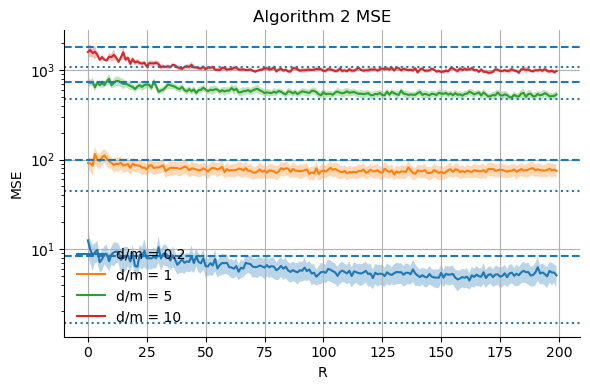

In [48]:
# Plot with shaded error bars (mean ± SEM)
labels = ['d/m = 0.2', 'd/m = 1', 'd/m = 5', 'd/m = 10']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(dims)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    plt.axhline(y = mean_mse_baseline[i], ls='--')
    plt.axhline(y = mean_mse_aggr[i], ls='dotted')
  
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('Algorithm 2 MSE')
plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
if save_data:
    df = pd.DataFrame(data=mean_mse.T)
    df.to_csv('Algo_2_mean_mse.csv', mode='a', index=True, header=None)

    df = pd.DataFrame(data=np.tile(mean_mse_baseline, [2,]).reshape(2,-1))
    df[5] = [-10,210]
    df = df.set_index(5)
    df.to_csv('Algo_2_mean_mse_baseline.csv', mode='a', index=True, header=None)

    df = pd.DataFrame(data=np.tile(mean_mse_aggr, [2,]).reshape(2,-1))
    df[5] = [-10,210]
    df = df.set_index(5)
    df.to_csv('Algo_2_mean_mse_aggr.csv', mode='a', index=True, header=None)

### Noise

In [58]:
#----------------Balanced clustered dataset (|C_1|=|C_2|=50)---------------------#
n_clusters = 2           # n.o. clusters 
n_i        = [50, 50]    # n.o. local datasets per cluster
m_i        = 10          # n.o. samples in local dataset
d          = 50
sigmas     = [0, 1.0, 10]     
eta        = 0.05        # learning rate
R          = 200        # n.o. iterations
S          = 20          # batch size
reps       = 10          # repeatitions of the experiment 

In [59]:
%%time
def experiment(n_clusters, n_i, m_i, d, eta, R, sigmas, S, **kwargs):

    params_len = len(sigmas)
    mse = np.zeros((params_len, R))
    baselines = np.zeros((params_len))
    loss_aggr = np.zeros((params_len))
    
    for i, sigma in enumerate(sigmas):
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        mse[i], baselines[i], loss_aggr[i] = train(ds_train, ds_val, cluster_labels, S, sigma, R, eta, **kwargs)
    return mse, baselines, loss_aggr

mse_reps  = np.zeros((reps, len(sigmas), R))
baselines_reps = np.zeros((reps, len(sigmas)))
loss_aggr_reps = np.zeros((reps, len(sigmas)))

for r in range(reps):
   mse_reps[r], baselines_reps[r], loss_aggr_reps[r] = experiment(n_clusters, n_i, m_i, d, eta, R, sigmas, S, max_depth=5)
    

CPU times: user 2min 29s, sys: 383 ms, total: 2min 29s
Wall time: 2min 30s


In [60]:
# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
mean_mse_baseline = np.mean(baselines_reps, axis=0)
mean_mse_aggr = np.mean(loss_aggr_reps, axis=0)

sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)
sem_bl  = np.std(mean_mse_baseline, axis=0, ddof=1) / np.sqrt(reps)
sem_aggr  = np.std(mean_mse_aggr, axis=0, ddof=1) / np.sqrt(reps)

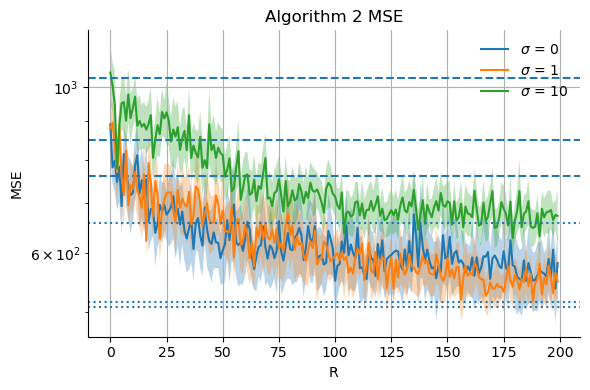

In [62]:
# Plot with shaded error bars (mean ± SEM)
labels = [r'$\sigma$ = 0', r'$\sigma$ = 1', r'$\sigma$ = 10']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(sigmas)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    plt.axhline(y = mean_mse_baseline[i], ls='--')
    plt.axhline(y = mean_mse_aggr[i], ls='dotted')
  
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('Algorithm 2 MSE')
plt.grid(True)
plt.tight_layout()
plt.show()

In [63]:
if save_data:
    df = pd.DataFrame(data=mean_mse.T)
    df.to_csv('Algo_2_mean_mse_noise.csv', mode='a', index=True, header=None)

    df = pd.DataFrame(data=np.tile(mean_mse_baseline, [2,]).reshape(2,-1))
    df[5] = [-10,210]
    df = df.set_index(5)
    df.to_csv('Algo_2_mean_mse_baseline_noise.csv', mode='a', index=True, header=None)

    df = pd.DataFrame(data=np.tile(mean_mse_aggr, [2,]).reshape(2,-1))
    df[5] = [-10,210]
    df = df.set_index(5)
    df.to_csv('Algo_2_mean_mse_aggr_noise.csv', mode='a', index=True, header=None)

### Subset size

In [76]:
#----------------Balanced clustered dataset (|C_1|=|C_2|=50)---------------------#
n_clusters = 2           # n.o. clusters 
n_i        = [50, 50]    # n.o. local datasets per cluster
m_i        = 10          # n.o. samples in local dataset
d          = 50   
eta        = 0.05        # learning rate
R          = 200        # n.o. iterations
sigma      = 0           # noise
Ss         = [5, 10, 30]    # batch size
reps       = 10          # repeatitions of the experiment 

In [77]:
%%time
def experiment(n_clusters, n_i, m_i, d, eta, R, sigma, Ss, **kwargs):

    params_len = len(Ss)
    mse = np.zeros((params_len, R))
    baselines = np.zeros((params_len))
    loss_aggr = np.zeros((params_len))
    
    for i, S in enumerate(Ss):
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        mse[i], baselines[i], loss_aggr[i] = train(ds_train, ds_val, cluster_labels, S, sigma, R, eta, **kwargs)
    return mse, baselines, loss_aggr

mse_reps  = np.zeros((reps, len(Ss), R))
baselines_reps = np.zeros((reps, len(Ss)))
loss_aggr_reps = np.zeros((reps, len(Ss)))

for r in range(reps):
   mse_reps[r], baselines_reps[r], loss_aggr_reps[r] = experiment(n_clusters, n_i, m_i, d, eta, R, sigma, Ss, max_depth=5)
    

CPU times: user 1min 55s, sys: 250 ms, total: 1min 55s
Wall time: 1min 55s


In [78]:
# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
mean_mse_baseline = np.mean(baselines_reps, axis=0)
mean_mse_aggr = np.mean(loss_aggr_reps, axis=0)

sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)
sem_bl  = np.std(mean_mse_baseline, axis=0, ddof=1) / np.sqrt(reps)
sem_aggr  = np.std(mean_mse_aggr, axis=0, ddof=1) / np.sqrt(reps)

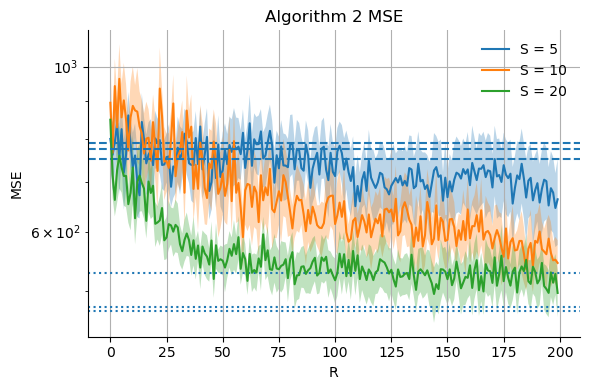

In [79]:
# Plot with shaded error bars (mean ± SEM)
labels = ['S = 5', 'S = 10', 'S = 20', 'S = 30']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(Ss)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    plt.axhline(y = mean_mse_baseline[i], ls='--')
    plt.axhline(y = mean_mse_aggr[i], ls='dotted')
  
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('Algorithm 2 MSE')
plt.grid(True)
plt.tight_layout()
plt.show()

In [80]:
if save_data:
    df = pd.DataFrame(data=mean_mse.T)
    df.to_csv('Algo_2_mean_mse_S.csv', mode='a', index=True, header=None)

    df = pd.DataFrame(data=np.tile(mean_mse_baseline, [2,]).reshape(2,-1))
    df[5] = [-10,210]
    df = df.set_index(5)
    df.to_csv('Algo_2_mean_mse_baseline_S.csv', mode='a', index=True, header=None)

    df = pd.DataFrame(data=np.tile(mean_mse_aggr, [2,]).reshape(2,-1))
    df[5] = [-10,210]
    df = df.set_index(5)
    df.to_csv('Algo_2_mean_mse_aggr_S.csv', mode='a', index=True, header=None)

### Different sample weight (regularization term), noise=0, S=20, d/m=2

In [ ]:
# def experiment(n_clusters, n_i, m_i, regenerate=False, **kwargs):
#     # other params of experiment
#     R     = 500
#     d     = 20
#     sigma = 0
#     S     = 20
    
#     # try out different reg.term / sample weight
#     etas = [0, 1, 10, 50]
#     cs = ['b', 'g', 'r', 'c']
    
#     params_len = len(etas)
#     mse = np.zeros((params_len, R))
#     baselines = np.zeros((params_len))
#     loss_oracle = np.zeros((params_len))
    
#     for i, eta in enumerate(etas): 
#         mse[i], baselines[i], loss_oracle[i] = train(n_clusters, m_i, d, S, sigma, R, eta, n_i, regenerate, **kwargs)
    
#     labels = ['reg.term = 0', 'reg.term = 1', 'reg.term = 10', 'reg.term = 50']
#     for i in range(params_len):
#         plt.plot(np.arange(R), mse[i]/loss_oracle[i], c=cs[i], label=labels[i])
#         plt.axhline(y = baselines[i]/loss_oracle[i], c=cs[i], ls='--')
#         plt.axhline(y=1, ls='--', c='k')
        
#     plt.xlabel('R')
#     plt.ylabel('relative MSE')
#     plt.yscale('log')
#     plt.legend(frameon=False)
#     plt.title('Algorithm 2, realtive MSE w.r.t. sample weight')
#     plt.show()    

### Different max_depth (d/m=2, S=20)

In [ ]:
# def experiment(n_clusters, n_i, m_i, regenerate=False, **kwargs):
#     R     = 500
#     d     = 20
#     sigma = 0
#     eta   = 1
#     S     = 20

#     # try out different max_depth
#     max_depths = [3, 5, 10]
#     cs = ['b', 'g', 'r', 'c']
    
#     params_len = len(max_depths)
#     mse = np.zeros((params_len, R))
#     baselines = np.zeros((params_len))
#     loss_oracle = np.zeros((params_len))
    
#     for i, max_depth in enumerate(max_depths):
#         mse[i], baselines[i], loss_oracle[i] = train(n_clusters, m_i, d, S, sigma, R, eta, n_i, regenerate, **{'max_depth': max_depth})
    
#     labels = ['max_depth = 3', 'max_depth = 5', 'max_depth = 10']
#     for i in range(params_len):
#         plt.plot(np.arange(R), mse[i]/loss_oracle[i], c=cs[i], label=labels[i])
#         plt.axhline(y = baselines[i]/loss_oracle[i], c=cs[i], ls='--')
#         plt.axhline(y=1, ls='--', c='k')
        
#     plt.xlabel('R')
#     plt.ylabel('relative MSE')
#     plt.yscale('log')
#     plt.legend(frameon=False)
#     plt.title(r'Algorithm 2, realtive MSE w.r.t. max_depth')
#     plt.show()